## Classification of Airline Tweets with RNNs
#### Project Overview
     This project focuses on performing sentiment analysis on a dataset of airline-related tweets. The goal is to classify
     each tweet into one of three categories: Positive, Neutral, or Negative.
#### Objective
     The primary objective is to gain hands-on experience with advanced Recurrent Neural Network (RNN) architectures using
     PyTorch. This implementation explores three key deep learning techniques:
     - Bidirectionality: Using a Bi-LSTM to capture context from both past and future words in a sequence.
     - Stacking: Using multiple LSTM layers to learn hierarchical representations of the text.
     - Attention Mechanism: Implementing a layer that allows the model to "focus" on specific words that carry the most
       emotional weight, rather than treating all words equally.
---

#### Data preparation
    For this project, we utilize a pre-cleaned and tokenized version of the Airline Tweets dataset. The data pipeline is
    implemented using an Object-Oriented (OO) approach:
    - TweetDataPreprocessor: Handles vocabulary building, word-to-index mapping, and sequence padding (using the 95th
    percentile length for efficiency).
    - TweetDataset: A custom PyTorch Dataset class that wraps the features and labels for the DataLoader.

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# Import from our custom src package
from src import (
    TweetDataPreprocessor,
    TweetDataset,
    StackedBiLSTMAttention,
    ModelTrainer,
    ModelEvaluator
)

preprocessor = TweetDataPreprocessor('../Datasets/preprocessed_tweets.csv')
X, y = preprocessor.process_data()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

train_dataset = TweetDataset(X_train, y_train)
val_dataset = TweetDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

#### Model Architecture: Stacked Bi-LSTM with Attention
    The model is designed to process text sequences through four distinct stages:
    1. Trainable Embedding Layer: Learns dense 100-dimensional vector representations for words during training.
    2. Stacked Bidirectional LSTM: A 2-layer LSTM that reads the sequence forward and backward. This allows the model to
      understand context like "not happy" by looking at the word "not" before it sees "happy."
    3. Attention Layer: Instead of just using the final hidden state, this layer calculates "energy scores" for every word
      in the tweet. Words like "excellent," "delayed," or "rude" receive higher weights, creating a context vector that
      summarizes the sentiment more accurately.
    4. Linear Classifier: A final fully connected layer that maps the attention-weighted context vector to the three target
      classes.

#### Model initialization

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = StackedBiLSTMAttention(
    vocab_size=preprocessor.vocab_size,
    embed_dim=100,
    hidden_dim=64,
    output_dim=3,
    num_layers=2,
    dropout=0.3
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

#### Model Training & Evaluation
     To maintain a clean separation of concerns, the training logic is divided into two specialized classes:
     - ModelTrainer: Manages the training loop, gradient descent, and loss tracking.
     - ModelEvaluator: Responsible for calculating validation metrics and generating visualizations such as learning
       curves and confusion matrices.

In [3]:
evaluator = ModelEvaluator(criterion, device)
trainer = ModelTrainer(model, optimizer, criterion, device)

trainer.train(epochs=5, train_loader=train_loader, val_loader=val_loader, evaluator=evaluator)

Starting training on device: cpu
Epoch 1/5 | Train Loss: 0.7505 | Val Loss: 0.6365
Epoch 2/5 | Train Loss: 0.5523 | Val Loss: 0.5940
Epoch 3/5 | Train Loss: 0.4450 | Val Loss: 0.5859
Epoch 4/5 | Train Loss: 0.3448 | Val Loss: 0.6368
Epoch 5/5 | Train Loss: 0.2551 | Val Loss: 0.6819


#### Results and Performance
     In this section, we visualize the model's performance to check for overfitting and classification accuracy
     across different categories.
     - Learning Curves: We observe the Training vs. Validation Loss to ensure the model is converging.
     - Confusion Matrix: This provides insight into which classes are being confused (e.g., if "Neutral" tweets
       are frequently misclassified as "Negative").

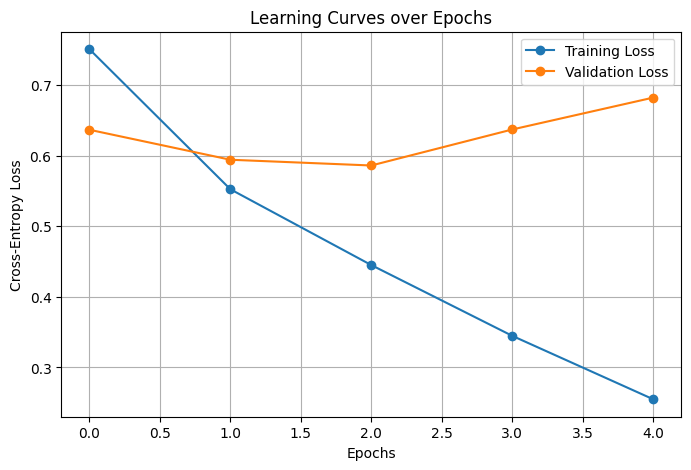

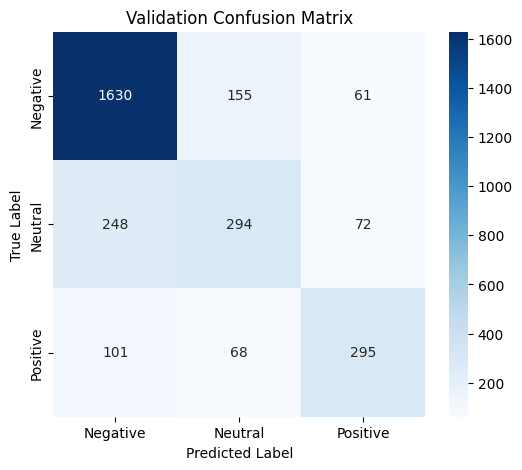

In [5]:
evaluator.plot_learning_curves(trainer.train_losses, trainer.val_losses)

_, y_true, y_pred = evaluator.evaluate(model, val_loader)
evaluator.plot_confusion_matrix(y_true, y_pred)

#### Discussion and Conclusion
1. Interpreting the Learning Curves
The training and validation loss curves provide a window into the model's learning process:

Convergence: We look for both curves to decrease steadily. A sharp drop in the first 2 epochs usually indicates the model has quickly identified the most common keywords associated with sentiment (e.g., "thanks," "worst," "delayed").

Overfitting: In RNNs with attention, it is common to see the training loss continue to drop while the validation loss plateaus or begins to rise slightly after a few epochs. This suggests the model is starting to memorize specific noise in the training tweets. If this happens, we might consider increasing the Dropout rate or using Early Stopping.

2. Analysis of the Confusion Matrix
The confusion matrix reveals how the model handles the three sentiment classes:

The "Negative" Dominance: Since the dataset is heavily skewed toward negative tweets, the model often becomes very good at identifying "Negative" sentiment but may struggle with "Neutral" and "Positive" classes.

Common Errors:

Neutral vs. Negative: Sarcasm is a major challenge for RNNs. A tweet like "Thanks for leaving me at the airport for 4 hours" contains positive words ("Thanks") but negative intent. The model might misclassify this as "Neutral" or "Positive" if it focuses too much on the word "Thanks."

Neutral vs. Positive: These classes are often confused when a tweet is a simple factual inquiry (e.g., "Are there flights to NYC?").

3. The Role of Attention
The addition of the Attention Mechanism is a significant upgrade over a standard LSTM.

In a standard LSTM, the "memory" of the first few words can fade by the time the model reaches the end of a long tweet.

With Attention, the model maintains a "focus" on high-impact words (like "horrible," "love," or "frustrated") regardless of where they appear in the sentence. This allows the model to produce a more nuanced "context vector" for the final classifier.

### Conclusion
Through this project, we successfully implemented a Stacked Bi-LSTM with Attention in an object-oriented PyTorch framework. The architecture leverages both past and future context while prioritizing the most informative words via attention weights.